In [15]:
import operator
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama

In [4]:
class ParallelState(TypedDict):
    topic: str
    results: Annotated[list, operator.add]

In [12]:
builder = StateGraph(ParallelState)

def researcher(state: ParallelState) -> ParallelState:
    return {
        "results": ["Research result 1", "Research result 2"]
    }

def twitter_node(state: ParallelState) -> ParallelState:
    return {
        "results": ["Twitter result 1", "Twitter result 2"]
    }

def linkedin_node(state: ParallelState) -> ParallelState:
    return {
        "results": ["LinkedIn result 1", "LinkedIn result 2"]
    }


builder.add_node("research", researcher)
builder.add_node("twitter", twitter_node)
builder.add_node("linkedin", linkedin_node)

builder.add_edge(START, "research")
builder.add_edge(START, "twitter")
builder.add_edge(START, "linkedin")

builder.add_edge("research", END)
builder.add_edge("twitter", END)
builder.add_edge("linkedin", END)

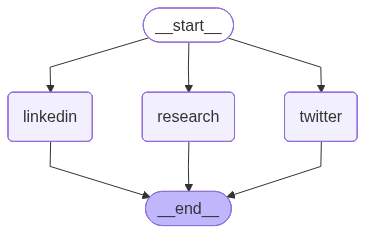

In [13]:
graph = builder.compile()
graph

In [14]:
graph.invoke({"topic": "Agentic AI in 2026"})

{'topic': 'Agentic AI in 2026',
 'results': ['LinkedIn result 1',
  'LinkedIn result 2',
  'Research result 1',
  'Research result 2',
  'Twitter result 1',
  'Twitter result 2']}

## Parallel Aggregator

In [17]:
class SEOSTATE(TypedDict):
    topic: str
    reports : Annotated[list, operator.add]
    final_audit : str

llm = ChatOllama(model="qwen2.5-coder:7b", temperature = 0)

In [22]:
def keyword_worker(state: SEOSTATE) -> SEOSTATE:
    print("---Running keyword analysis---")
    prompt = f"Identify 3 high-volume SEO keywords for this topic: {state['topic']}"
    response = llm.invoke(prompt)
    return {
        "reports": [f"Keywords: {response.content}"]
    }

def competitor_worker(state: SEOSTATE) -> SEOSTATE:
    print("---Running competitor analysis---")
    prompt = f"What are top 3 main competitors for this topic: {state['topic']}"
    response = llm.invoke(prompt)
    return {
        "reports": [f"Competitors: {response.content}"]
    }

def technical_worker(state: SEOSTATE) -> SEOSTATE:
    print("---Running technical SEO analysis---")
    prompt = f"what are 3 technical SEO improvements for this topic: {state['topic']}"
    response = llm.invoke(prompt)
    return {
        "reports": [f"Technical SEO: {response.content}"]
    }

def aggregator_node(state: SEOSTATE) -> SEOSTATE:
    print("---Aggregating reports---")
    combined_report = "\n".join(state["reports"])
    prompt = f"Based on the following reports, provide a final SEO audit for the topic '{state['topic']}':\n{combined_report}"
    response = llm.invoke(prompt)
    return {
        "final_audit": f"Final SEO Audit:\n{response.content}"
    }

In [23]:
builder = StateGraph(SEOSTATE)

builder.add_node("keywords", keyword_worker)
builder.add_node("competitor", competitor_worker)
builder.add_node("technical", technical_worker)
builder.add_node("manager", aggregator_node)

builder.add_edge(START, "keywords")
builder.add_edge(START, "competitor")
builder.add_edge(START, "technical")

builder.add_edge("keywords", "manager")
builder.add_edge("competitor", "manager")
builder.add_edge("technical", "manager")

builder.add_edge("manager", END)

seo_agent = builder.compile()

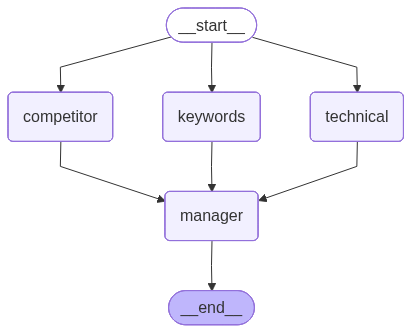

In [24]:
seo_agent

In [25]:
result = seo_agent.invoke({
    "topic": "Agentic AI in E-Commerce"
})

print(result["final_audit"])

---Running competitor analysis---
---Running keyword analysis---
---Running technical SEO analysis---
---Aggregating reports---
Final SEO Audit:
### SEO Audit for "Agentic AI in E-Commerce"

#### Competitor Analysis:
1. **Amazon's Alexa and Echo Devices**:
   - **Strengths**: Utilize natural language processing to understand customer queries, providing a seamless shopping experience.
   - **Weaknesses**: Primarily designed as standalone devices rather than integrated solutions for e-commerce platforms.

2. **Google Assistant**:
   - **Strengths**: Offers personalized shopping experiences through features like product recommendations and order tracking.
   - **Weaknesses**: Limited integration options compared to some competitors, which might limit its effectiveness in complex e-commerce environments.

3. **Microsoft's Cortana**:
   - **Strengths**: Highly customizable and can be integrated into various devices and platforms, making it versatile for e-commerce use.
   - **Weaknesses**: 